In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from keras.callbacks import LambdaCallback
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

In [2]:
data = np.load('C:/Users/rafin/Desktop/HSIC/Blueberry/Datasets/SM/All_SM.npy', allow_pickle= True)
data.shape

(423, 463)

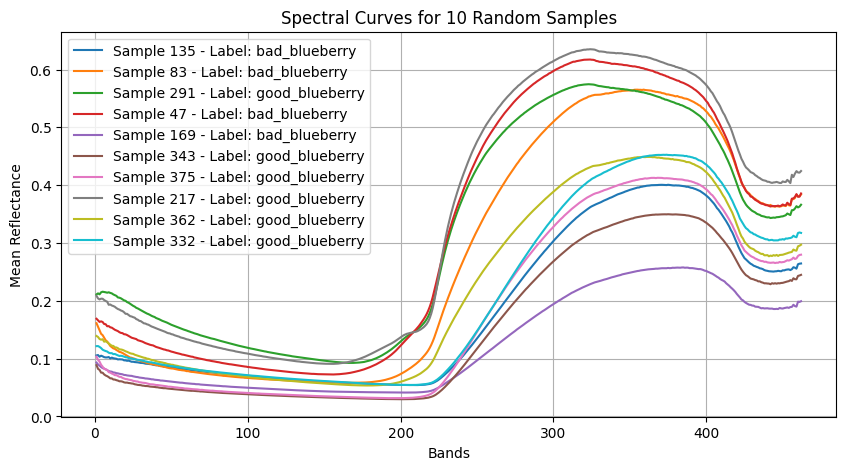

In [36]:
def plot_random_spectral_curves(data, num_samples):
    
    # Exclude the label column
    spectral_data = data[:, :-1]
    labels = data[:, -1]

    # Randomly choose `num_samples` rows
    random_indices = np.random.choice(spectral_data.shape[0], num_samples, replace=False)

    plt.figure(figsize=(10, 5))

    for i, idx in enumerate(random_indices):
        
        # Extract the label
        label = labels[idx]

        # Extract the spectral values
        spectral_values = spectral_data[idx].astype(float)
        wavelengths = np.arange(1, spectral_values.shape[0] + 1)

        # Plot the spectral curve
        plt.plot(wavelengths, spectral_values, label=f"Sample {idx} - Label: {label}")

    plt.title(f"Spectral Curves for {num_samples} Random Samples")
    plt.xlabel("Bands")
    plt.ylabel("Mean Reflectance")
    plt.grid(True)
    plt.legend()
    plt.show()
    
plot_random_spectral_curves(data, num_samples = 10)

In [5]:
X= data[:, :-1]
y= data[:, -1]  

X.shape, y.shape

((423, 462), (423,))

In [6]:
scaler = StandardScaler()
scaler.fit(X)

Xn = scaler.transform(X)

In [8]:
# Split data into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(Xn, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape,y_train.shape,X_test.shape

((338, 462), (338,), (85, 462))

In [13]:
# Initialize the encoder
le= LabelEncoder()
y_encoded= le.fit_transform(y)

X_train2, X_test2, y_train2, y_test2 = train_test_split(Xn, y_encoded, test_size=0.2, random_state=42)

X_train2.shape,y_train2.shape

((338, 462), (338,))

In [14]:
unique_classes = np.unique(y)
print(unique_classes)

unique_classes_encoded = np.unique(y_encoded)
print(unique_classes_encoded)

['bad_blueberry' 'good_blueberry']
[0 1]


PAPER HYPERPARAMS

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree with 'gini' criterion
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

accuracy_gini = accuracy_score(y_test, dt_gini.predict(X_test))

print("Decision Tree with Gini Accuracy:", accuracy_gini * 100)

Decision Tree with Gini Accuracy: 72.94117647058823


In [16]:
# Decision Tree with 'entropy' criterion
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt_entropy.fit(X_train, y_train)

accuracy_entropy = accuracy_score(y_test, dt_entropy.predict(X_test))
print("Decision Tree with Entropy Accuracy:", accuracy_entropy * 100)

Decision Tree with Entropy Accuracy: 69.41176470588235


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest: 100 trees, 'log_loss' criterion
rf_log_loss = RandomForestClassifier(n_estimators=100, criterion='log_loss', random_state=42)
rf_log_loss.fit(X_train, y_train)

accuracy_rf_log_loss = accuracy_score(y_test, rf_log_loss.predict(X_test))

print("Random Forest (log_loss, 100 trees) Accuracy:", accuracy_rf_log_loss * 100)

Random Forest (log_loss, 100 trees) Accuracy: 74.11764705882354


In [18]:
# Random Forest: 50 trees, 'entropy' criterion
rf_50_entropy = RandomForestClassifier(n_estimators=50, criterion='entropy', random_state=42)
rf_50_entropy.fit(X_train, y_train)

accuracy_rf_50_entropy = accuracy_score(y_test, rf_50_entropy.predict(X_test))

print("Random Forest (50 trees, entropy) Accuracy:", accuracy_rf_50_entropy * 100)

Random Forest (50 trees, entropy) Accuracy: 74.11764705882354


In [19]:
# Random Forest: 90 trees, 'entropy' criterion
rf_90_entropy = RandomForestClassifier(n_estimators=90, criterion='entropy', random_state=42)
rf_90_entropy.fit(X_train, y_train)

accuracy_rf_90_entropy = accuracy_score(y_test, rf_90_entropy.predict(X_test))

print("Random Forest (90 trees, entropy) Accuracy:", accuracy_rf_90_entropy * 100)

Random Forest (90 trees, entropy) Accuracy: 74.11764705882354


In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression: No penalty, solver 'newton-cg'
lr_no_penalty = LogisticRegression(penalty=None, solver='newton-cg', random_state=42)
lr_no_penalty.fit(X_train, y_train)

accuracy_lr_no_penalty = accuracy_score(y_test, lr_no_penalty.predict(X_test))

print("Logistic Regression (No penalty) Accuracy:", accuracy_lr_no_penalty * 100)

Logistic Regression (No penalty) Accuracy: 96.47058823529412


In [24]:
# Logistic Regression: L2 penalty, solver 'lbfgs'
lr_l2_lbfgs = LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, max_iter=1000)
lr_l2_lbfgs.fit(X_train, y_train)

accuracy_lr_l2_lbfgs = accuracy_score(y_test, lr_l2_lbfgs.predict(X_test))
print("Logistic Regression (L2 penalty, lbfgs) Accuracy:", accuracy_lr_l2_lbfgs * 100)

Logistic Regression (L2 penalty, lbfgs) Accuracy: 88.23529411764706


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting: 150 stages
gb_150 = GradientBoostingClassifier(n_estimators=150, random_state=42)
gb_150.fit(X_train, y_train)
accuracy_gb_150 = accuracy_score(y_test, gb_150.predict(X_test))
print("Gradient Boosting (150 stages) Accuracy:", accuracy_gb_150 * 100)

# Gradient Boosting: 450 stages
gb_450 = GradientBoostingClassifier(n_estimators=450, random_state=42)
gb_450.fit(X_train, y_train)
accuracy_gb_450 = accuracy_score(y_test, gb_450.predict(X_test))
print("Gradient Boosting (450 stages) Accuracy:", accuracy_gb_450 * 100)

# Gradient Boosting: 250 stages
gb_250 = GradientBoostingClassifier(n_estimators=250, random_state=42)
gb_250.fit(X_train, y_train)
accuracy_gb_250 = accuracy_score(y_test, gb_250.predict(X_test))
print("Gradient Boosting (250 stages) Accuracy:", accuracy_gb_250 * 100)


Gradient Boosting (150 stages) Accuracy: 70.58823529411765
Gradient Boosting (450 stages) Accuracy: 71.76470588235294
Gradient Boosting (250 stages) Accuracy: 70.58823529411765


OUR HYPERPARAMS

In [9]:
param_grid = {
    
    'n_neighbors': [3, 5],  # Use fewer values to test
    'weights': ['uniform'],  # Try with just one weight for now
    'metric': ['euclidean']  # Test one distance metric at a time
}

# KNN classifier
knn_classifier = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Training
grid_search_knn.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean'], 'n_neighbors': [3, 5],
                         'weights': ['uniform']},
             scoring='accuracy')

In [10]:
# test Accuracy
y_test_pred = grid_search_knn.predict(X_test)

accuracy = np.mean(y_test_pred == y_test) * 100
print("Test Accuracy:", accuracy)

Test Accuracy: 75.29411764705883


In [26]:
# Train XGBoost
xgb_classifier = XGBClassifier()

# Define parameter grid for GridSearchCV
param_grid = {
    'max_depth': [7],
    'learning_rate': [0.01],
    'n_estimators': [100]
}


# GridSearchCV for XGBoost Classifier
xgb_grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, cv=5, scoring='accuracy')
xgb_grid_search.fit(X_train2, y_train2)

# Get best parameters for XGBoost Classifier
best_params = xgb_grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}


In [27]:
# Get the best estimator
best_xgb_model = xgb_grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test2)

# Calculate the accuracy
accuracy = accuracy_score(y_test2, y_pred)
print("Accuracy:", accuracy*100)

Accuracy: 80.0


In [28]:
from sklearn.svm import SVC

param_dist = {
    
    'C': [0.1, 1, 10, 100],         
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],  
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4, 5], 
    'coef0': [0.0, 0.1, 0.5, 1.0] 
    
}
# SVM classifier
svc = SVC()

# Instantiate the grid search
random_search = RandomizedSearchCV(svc, param_distributions=param_dist, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)

# Training
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'coef0': [0.0, 0.1, 0.5, 1.0],
                                        'degree': [2, 3, 4, 5],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf', 'poly',
                                                   'sigmoid']},
                   random_state=42, verbose=2)

In [29]:
# Best parameters found by RandomizedSearchCV
print("Best parameters:", random_search.best_params_)

# Use the best model to predict on the test data
y_pred = random_search.best_estimator_.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100)

Best parameters: {'kernel': 'linear', 'gamma': 'scale', 'degree': 4, 'coef0': 0.1, 'C': 10}
Accuracy: 91.76470588235294


In [30]:
from sklearn.naive_bayes import GaussianNB

# Initialize Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

GaussianNB()

In [31]:
# test Accuracy
y_test_pred = nb_classifier.predict(X_test)

accuracy = np.mean(y_test_pred == y_test) * 100
print("Test Accuracy:", accuracy)

Test Accuracy: 61.1764705882353


In [32]:
config = tf.compat.v1.ConfigProto(gpu_options =
                         tf.compat.v1.GPUOptions(per_process_gpu_memory_fraction=0.8)
)

config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)
tf.compat.v1.keras.backend.set_session(session)

physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))


Num GPUs Available:  1


In [33]:
#Neural Network

tf.random.set_seed(1234) # for consistent results

model = Sequential(
    [
        tf.keras.Input(shape=(462,)),
        Dense(units=30, activation='relu', kernel_regularizer=regularizers.l2(0.001), name='layer1'),
        #Dense(units=15, activation='relu', kernel_regularizer=regularizers.l2(0.001), name='layer2'),
        #Dense(units=8, activation='relu', kernel_regularizer=regularizers.l2(0.0001), name='layer3'),
        
        Dense(units=2, activation='linear')
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer1 (Dense)              (None, 30)                13890     
                                                                 
 dense (Dense)               (None, 2)                 62        
                                                                 
Total params: 13,952
Trainable params: 13,952
Non-trainable params: 0
_________________________________________________________________


In [34]:
#Training

model.compile(
    
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-2),
)

model.fit(
    
    X_train2,y_train2,
    batch_size = 500,
    epochs = 1000,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor = 'loss',
            patience = 500,
            restore_best_weights = True
        )
    ]
)

Epoch 1/1000
1/1 [==============================] - 1s 939ms/step - loss: 1.2191
Epoch 2/1000
1/1 [==============================] - 0s 6ms/step - loss: 4.0699
Epoch 3/1000
1/1 [==============================] - 0s 5ms/step - loss: 3.6106
Epoch 4/1000
1/1 [==============================] - 0s 4ms/step - loss: 2.0912
Epoch 5/1000
1/1 [==============================] - 0s 4ms/step - loss: 1.0131
Epoch 6/1000
1/1 [==============================] - 0s 2ms/step - loss: 1.9904
Epoch 7/1000
1/1 [==============================] - 0s 4ms/step - loss: 1.8872
Epoch 8/1000
1/1 [==============================] - 0s 5ms/step - loss: 0.9489
Epoch 9/1000
1/1 [==============================] - 0s 4ms/step - loss: 0.7864
Epoch 10/1000
1/1 [==============================] - 0s 4ms/step - loss: 1.1217
Epoch 11/1000
1/1 [==============================] - 0s 5ms/step - loss: 1.2677
Epoch 12/1000
1/1 [==============================] - 0s 4ms/step - loss: 1.1590
Epoch 13/1000
1/1 [============================

In [35]:
predictions = model.predict(X_test2)
predicted_labels = np.argmax(predictions, axis=1)

#Accuracy
# Calculate total accuracy
total_accuracy = accuracy_score(y_test2, predicted_labels)

print(f"Total Test Accuracy: {total_accuracy*100}")

3/3 [==============================] - 0s 1ms/step
Total Test Accuracy: 77.64705882352942
